Top 10 Directors by Average IMDB Rating (with at least 2 films):
                          mean  count Rating_Category
Director                                             
Frank Darabont        8.950000      2         8.5-9.0
Milos Forman          8.500000      2         8.5-9.0
Christopher Nolan     8.462500      8         8.0-8.5
Francis Ford Coppola  8.400000      5         8.0-8.5
Peter Jackson         8.400000      5         8.0-8.5
Charles Chaplin       8.333333      6         8.0-8.5
Nitesh Tiwari         8.300000      2         8.0-8.5
Lee Unkrich           8.300000      2         8.0-8.5
Fritz Lang            8.300000      2         8.0-8.5
Sergio Leone          8.266667      6         8.0-8.5

Rating Category Distribution:
Rating_Category
7.5-8.0    336
8.0-8.5    200
8.5-9.0     12
Name: count, dtype: int64


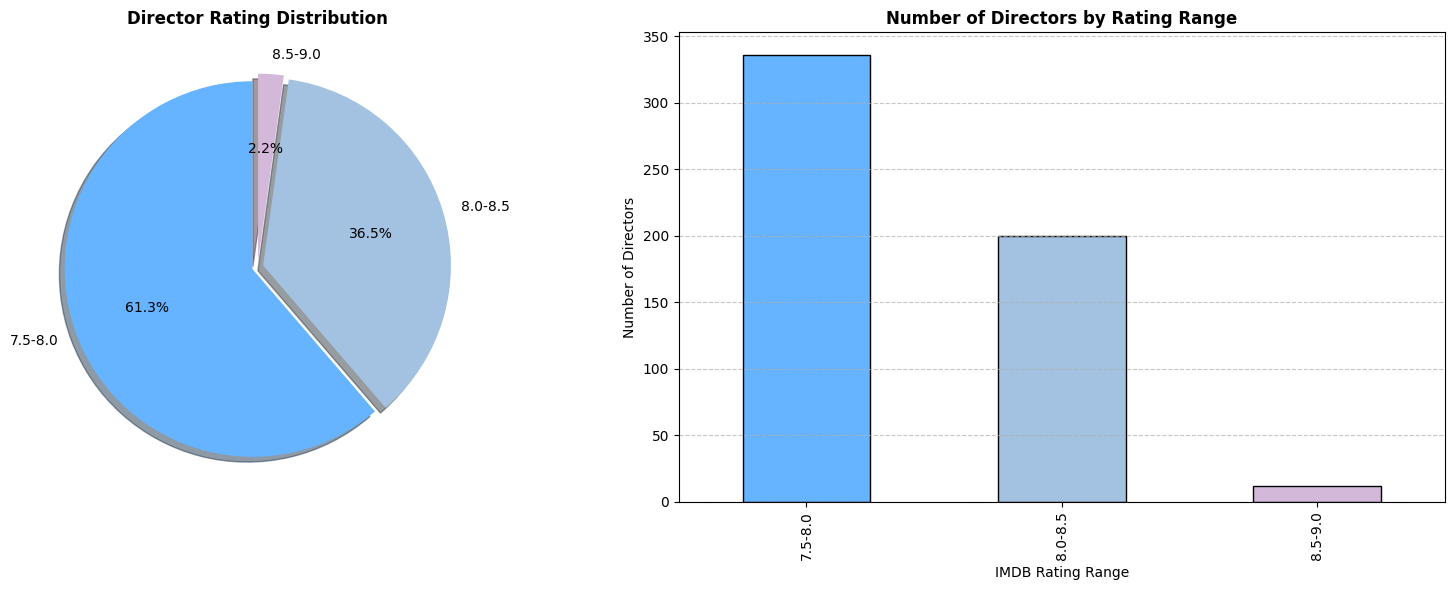

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def load_data():
    movie_data = pd.read_csv("imdb_top_1000.csv")
    movie_data = movie_data[["Series_Title", "IMDB_Rating", "Director", "Gross"]]

    movie_data['Gross'] = movie_data['Gross'].str.replace(r'[$,]', '', regex=True).astype(float)
    return movie_data

def analyze_director_ratings(df):
    director_avg = df.groupby('Director')['IMDB_Rating'].agg(['mean', 'count'])
    director_avg = director_avg.sort_values('mean', ascending=False)

    bins = [ 7.5, 8.0, 8.5, 9.0]
    labels = [ '7.5-8.0', '8.0-8.5', '8.5-9.0']
    director_avg['Rating_Category'] = pd.cut(director_avg['mean'], bins=bins, labels=labels, right=False)
    
    return director_avg


def plot_director_ratings(director_avg):

    class_counts = director_avg['Rating_Category'].value_counts().sort_index()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    colors = ['#66b3ff', '#a3c1e0', '#d4b8d9']
    explode = [0.03] * len(class_counts)
    
    ax1.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors, explode=explode,
            shadow=True, textprops={'fontsize': 10})
    ax1.set_title('Director Rating Distribution', fontweight='bold')
    
    class_counts.sort_index().plot(kind='bar', ax=ax2, color=colors, edgecolor='black')
    ax2.set_title('Number of Directors by Rating Range', fontweight='bold')
    ax2.set_xlabel('IMDB Rating Range')
    ax2.set_ylabel('Number of Directors')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

movie_data = load_data()
director_stats = analyze_director_ratings(movie_data)
print("Top 10 Directors by Average IMDB Rating (with at least 2 films):")
print(director_stats[director_stats['count'] >= 2].head(10).to_string())

print("\nRating Category Distribution:")
print(director_stats['Rating_Category'].value_counts().sort_index())

plot_director_ratings(director_stats)

Top 20 Actors by Average IMDB Rating (with at least 2 films):
                    Average_Rating  Movie_Count
Actor                                          
Elijah Wood               8.800000            3
Orlando Bloom             8.600000            4
Carrie-Anne Moss          8.550000            2
Lee Van Cleef             8.550000            2
Mark Hamill               8.533333            3
Billy Dee Williams        8.500000            2
Edward Furlong            8.500000            2
Madhavan                  8.466667            3
Paulette Goddard          8.450000            2
Marlon Brando             8.425000            4
Paul Reiser               8.400000            2
Lee J. Cobb               8.366667            3
Çetin Tekindor            8.350000            2
Heath Ledger              8.350000            2
Miyu Irino                8.350000            2
Henry Bergman             8.350000            2
John Fiedler              8.350000            2
James Caan                

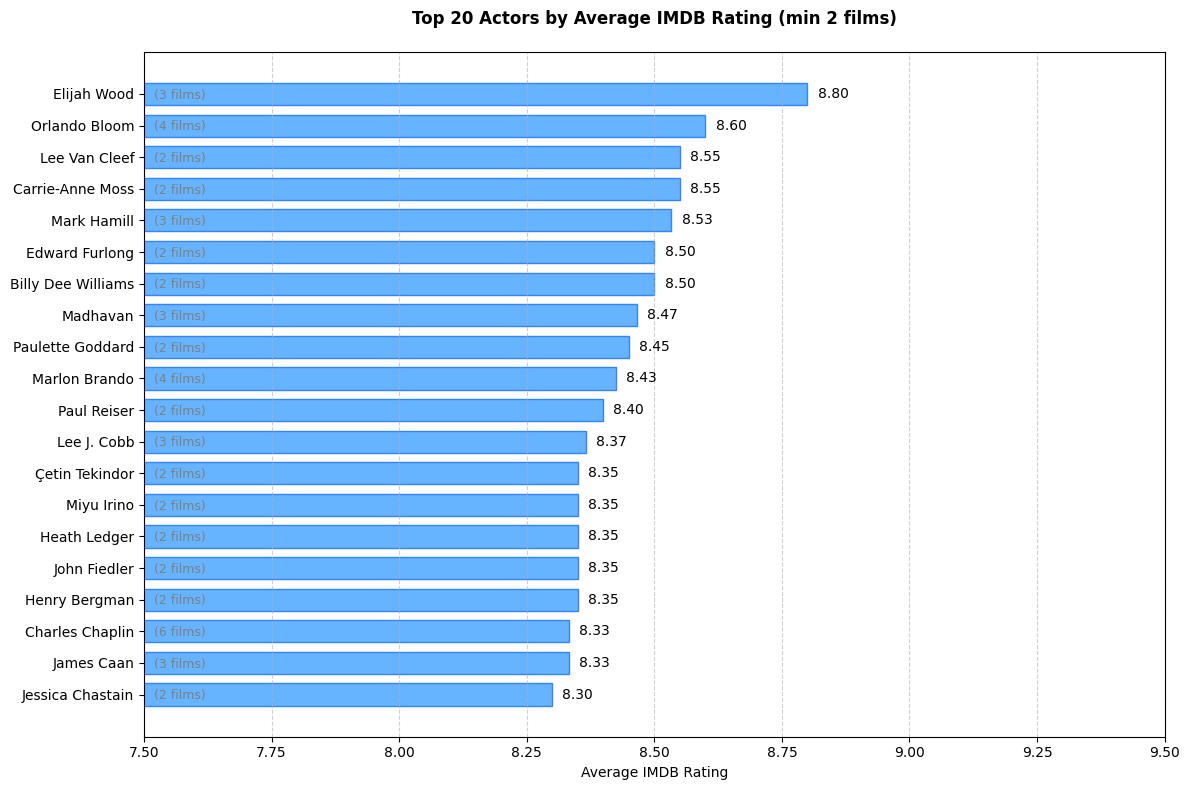

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def load_data():
    movie_data = pd.read_csv("imdb_top_1000.csv")
    movie_data = movie_data[["Series_Title", "IMDB_Rating", "Star1", "Star2", "Star3", "Star4"]]
    return movie_data

def calculate_actor_ratings(df):
    actors_df = df.melt(
        id_vars=["Series_Title", "IMDB_Rating"], 
        value_vars=["Star1", "Star2", "Star3", "Star4"],
        var_name="Star_Type", 
        value_name="Actor"
    )
    
    actor_stats = actors_df.groupby('Actor')['IMDB_Rating'].agg(['mean', 'count'])
    actor_stats.columns = ['Average_Rating', 'Movie_Count']
    
    significant_actors = actor_stats[actor_stats['Movie_Count'] >= 2]
    
    return significant_actors.sort_values('Average_Rating', ascending=False)

def plot_actor_ratings(actor_stats, top_n=20):
    top_actors = actor_stats.head(top_n).sort_values('Average_Rating')
    
    plt.figure(figsize=(12, 8))
    bars = plt.barh(
        top_actors.index, 
        top_actors['Average_Rating'],
        color='#66b3ff',
        edgecolor='#3385ff',
        height=0.7
    )
    
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 0.02, 
            bar.get_y() + bar.get_height()/2,
            f'{width:.2f}',
            va='center',
            fontsize=10
        )
    
    plt.title(f'Top {top_n} Actors by Average IMDB Rating (min 2 films)', pad=20, fontweight='bold')
    plt.xlabel('Average IMDB Rating')
    plt.xlim(7.5, 9.5)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    for i, actor in enumerate(top_actors.index):
        count = top_actors.loc[actor, 'Movie_Count']
        plt.text(
            7.52, 
            i - 0.15,
            f'({count} films)',
            color='gray',
            fontsize=9
        )
    
    plt.tight_layout()
    plt.show()

movie_data = load_data()
actor_stats = calculate_actor_ratings(movie_data)

print("Top 20 Actors by Average IMDB Rating (with at least 2 films):")
print(actor_stats.head(20).to_string())

plot_actor_ratings(actor_stats)

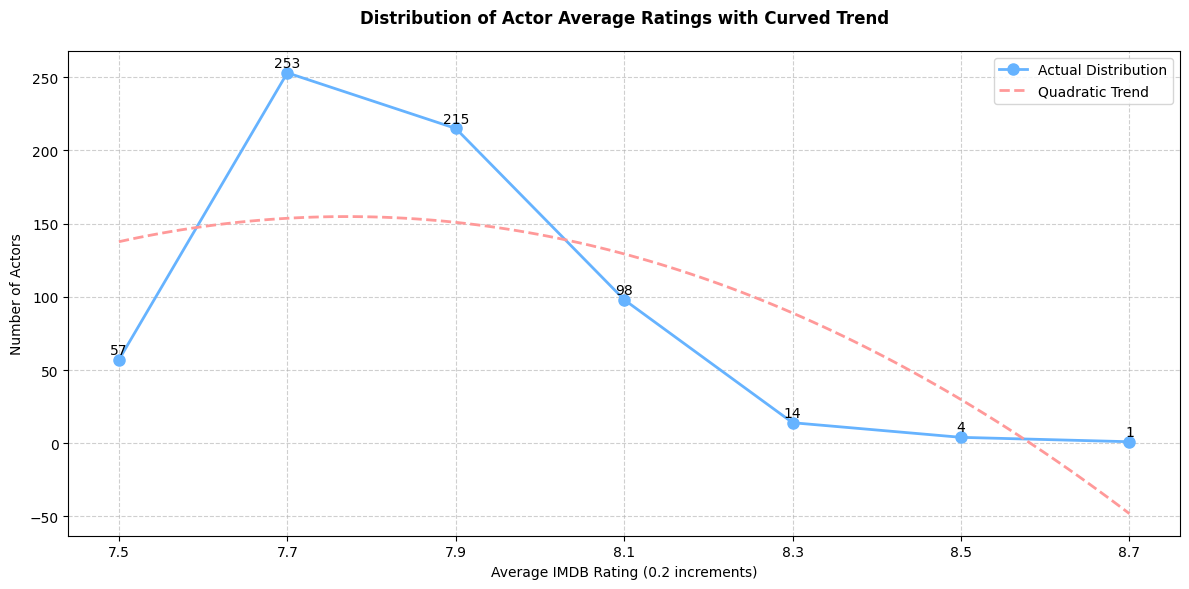

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def plot_rating_distribution(actor_stats):

    bins = np.arange(7.5, 9.01, 0.2)
    actor_stats['Rating_Bin'] = pd.cut(actor_stats['Average_Rating'], bins=bins)
    bin_counts = actor_stats['Rating_Bin'].value_counts().sort_index()
    

    x = [interval.mid for interval in bin_counts.index]
    y = bin_counts.values
    
    coeffs = np.polyfit(x, y, 2)
    polynomial = np.poly1d(coeffs)
    trend_line = polynomial(x)
    
    x_smooth = np.linspace(min(x), max(x), 100)
    trend_smooth = polynomial(x_smooth)
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(x, y, 'o-', color='#66b3ff', linewidth=2, markersize=8, 
             label='Actual Distribution')
    
    plt.plot(x_smooth, trend_smooth, '--', color='#ff9999', linewidth=2,
             label='Quadratic Trend')
    
    plt.title('Distribution of Actor Average Ratings with Curved Trend', 
              fontweight='bold', pad=20)
    plt.xlabel('Average IMDB Rating (0.2 increments)')
    plt.ylabel('Number of Actors')
    plt.xticks(bins[:-1] + 0.1, [f'{b:.1f}' for b in bins[:-1]])
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    for xi, yi in zip(x, y):
        plt.text(xi, yi + 2, str(yi), ha='center', va='bottom', fontsize=10)
    
    equation = f'y = {coeffs[0]:.2f}x² + {coeffs[1]:.2f}x + {coeffs[2]:.2f}'
    # plt.text(0.02, 0.95, equation, transform=plt.gca().transAxes,
    #          fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

movie_data = load_data()
actor_stats = calculate_actor_ratings(movie_data)
plot_rating_distribution(actor_stats)